## Filter Out Odd `discharge` Values

__Method:__

It computes the rolling standard deviation with a specified window size. The min_periods parameter ensures that the window is only considered complete when it contains the full number of days.

1. Check for the odd values

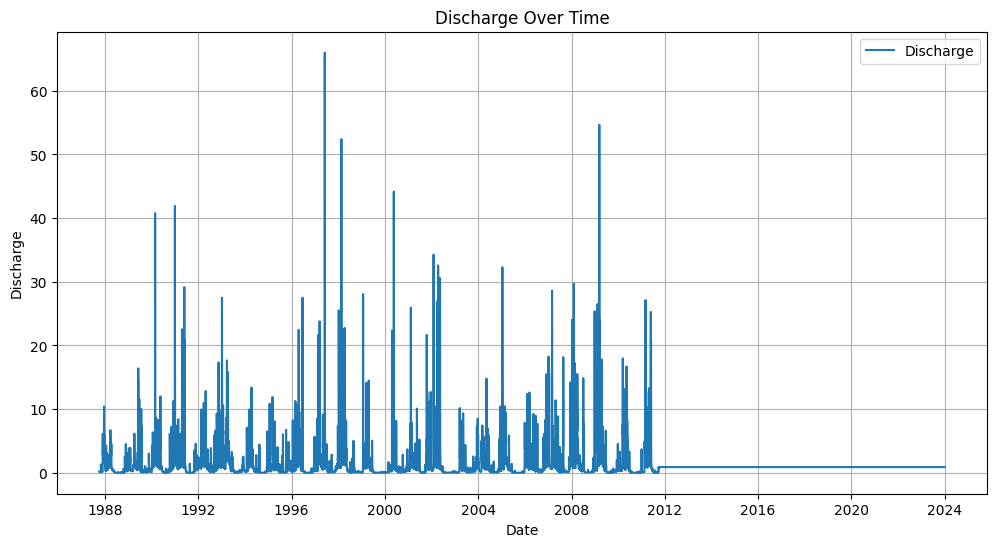

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

def get_file_name(basin_id: str):
    file_name = str(basin_id) + ".csv"

    return "csv_files/" + file_name 

csv_path = get_file_name("04176605")

# Read the CSV file with "date" as an index
df = pd.read_csv(csv_path, index_col='date', parse_dates=True)

# Plot the "discharge" column
plt.figure(figsize=(12, 6))
plt.plot(df['discharge'], label='Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.title('Discharge Over Time')
plt.legend()
plt.grid(True)
plt.show()

2. Process the files and save to a new file

In [6]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Define input and output directories
data_dir = "csv_files"
output_dir = "csv_filtered"

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Parameters for detecting suspicious data
window_size = 14               # Rolling window length (days)
std_threshold = 1e-5           # Threshold for standard deviation

# Process each CSV file
for filename in tqdm(os.listdir(data_dir)):
    if not filename.endswith(".csv"):
        continue
    
    csv_path = os.path.join(data_dir, filename)
    df = pd.read_csv(csv_path)
    
    # Ensure 'discharge' column exists
    if "discharge" not in df.columns:
        continue

    # Compute rolling standard deviation for the 'discharge' column
    rolling_std = df["discharge"].rolling(window=window_size, min_periods=window_size).std()
    
    # For each complete rolling window, if the standard deviation is below the threshold,
    # set the corresponding window of "discharge" values to NaN.
    for i in range(window_size - 1, len(df)):
        if pd.notna(rolling_std.iloc[i]) and rolling_std.iloc[i] < std_threshold:
            start_index = i - window_size + 1
            df.loc[start_index:i, "discharge"] = np.nan
    
    # Save the modified DataFrame in the output directory using the same filename
    output_path = os.path.join(output_dir, filename)
    df.to_csv(output_path, index=False)

print("Processing complete. Filtered CSV files saved to '{}'.".format(output_dir))


100%|██████████| 976/976 [04:51<00:00,  3.35it/s]

Processing complete. Filtered CSV files saved to 'csv_filtered'.


3. Check the new file for odd values

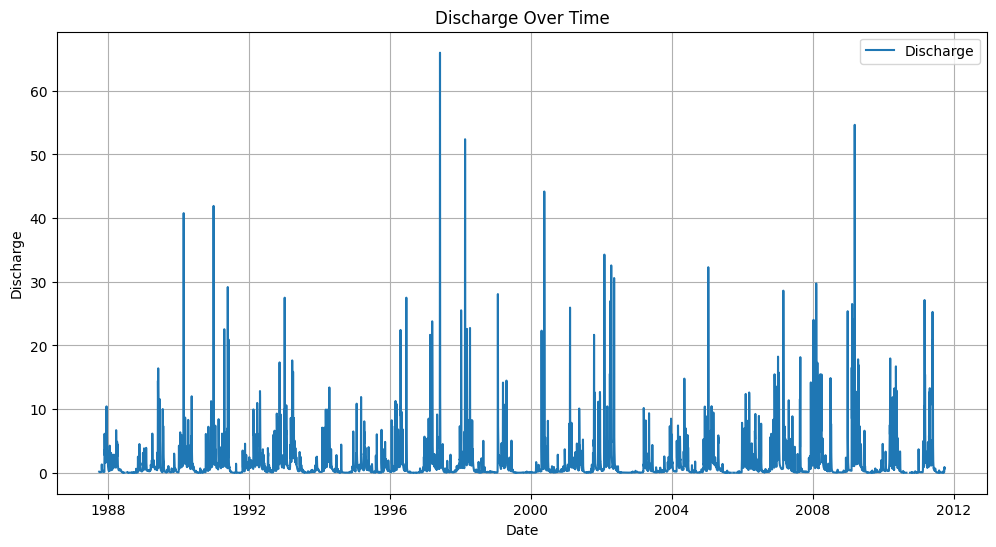

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def get_file_name(basin_id: str):
    file_name = str(basin_id) + ".csv"

    return "csv_filtered/" + file_name 

csv_path = get_file_name("04176605")

# Read the CSV file with "date" as an index
df = pd.read_csv(csv_path, index_col='date', parse_dates=True)

# Plot the "discharge" column
plt.figure(figsize=(12, 6))
plt.plot(df['discharge'], label='Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.title('Discharge Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Prepare Metadata for Reference

In [13]:
import geopandas as gpd
US_shape = gpd.read_file("shapefile/GL_GAGE2_all.shp")


In [12]:
import geopandas as gpd
Canada_shape = gpd.read_file("shapefile/ADP02_Basin_Select.shp")

(array([350.,  37.,  21.,  11.,   4.,   6.,   1.,   1.,   4.,   4.]),
 array([0.00000000e+00, 1.64497734e+09, 3.28995468e+09, 4.93493202e+09,
        6.57990936e+09, 8.22488670e+09, 9.86986404e+09, 1.15148414e+10,
        1.31598187e+10, 1.48047961e+10, 1.64497734e+10]),
 <BarContainer object of 10 artists>)

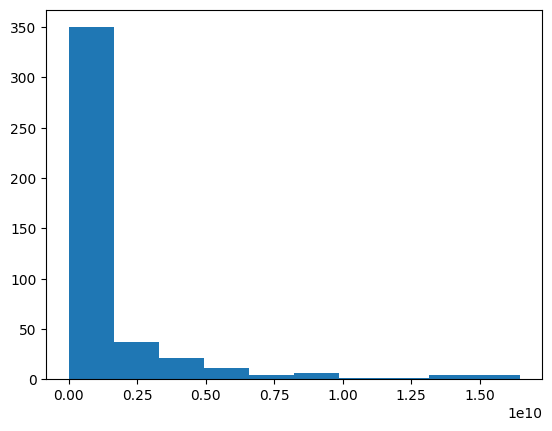

In [ ]:
import matplotlib.pyplot as plt
US_shape

In [21]:
US_shape.head()


AttributeError: 'NoneType' object has no attribute 'copy'

,AREA,PERIMETER,GAGE_ID,MERGE_SRC,Shape_Leng,Shape_Area,geometry
0,3.447920e+08,155520.0,04014500,None,0.0,0.0,"POLYGON ((351119.969 2736780, 351089.969 27367..."
1,2.243540e+08,102060.0,04015330,None,0.0,0.0,"POLYGON ((319515 2689545, 319515 2689575, 3195..."
2,2.009250e+07,37440.0,04024098,None,0.0,0.0,"POLYGON ((274005 2624805, 274005 2624775, 2740..."
3,1.091250e+09,277380.0,04024430,None,0.0,0.0,"POLYGON ((271305 2631585, 271305 2631615, 2713..."
4,1.619850e+09,366120.0,04027000,None,0.0,0.0,"POLYGON ((416520 2625420, 416520 2625450, 4165..."


In [ ]:
Canada_shape.desc

,Area_km2,Aire_km2,Date_rev,Shape_Leng,Shape_Area
count,649.000000,649.000000,649,6.490000e+02,6.490000e+02
mean,1339.113620,1339.113682,2024-06-01 00:00:00,2.938052e+05,1.339114e+09
min,4.077900,4.077900,2024-06-01 00:00:00,1.362000e+04,4.077900e+06
25%,74.960100,74.960100,2024-06-01 00:00:00,7.410000e+04,7.496010e+07
50%,225.950000,225.950000,2024-06-01 00:00:00,1.377600e+05,2.259504e+08
75%,1122.980000,1122.980000,2024-06-01 00:00:00,3.575400e+05,1.122977e+09
max,15463.100000,15463.100000,2024-06-01 00:00:00,1.890120e+06,1.546307e+10
std,2705.619787,2705.619787,NaN,3.584441e+05,2.705620e+09


## _TODO: Correct the `shape_ratio` values using the above shapefile dataframes_

In [ ]:
import os
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm import tqdm
import geopandas as gpd

# Define paths
csv_dir = "csv_filtered"         # Folder with CSV files
shp_dir = "shp_wgs84"                # Folder with shapefiles
output_meta = "meta_data.csv"        # Output metadata file

# Initialize list for metadata rows
meta_rows = []

# Define the training period (1981-01-01 to 2010-12-31)
train_start = pd.to_datetime("1980-01-01")
train_end = pd.to_datetime("2010-12-31")

# Loop over each CSV file
for filename in tqdm(os.listdir(csv_dir)):
    if not filename.endswith(".csv"):
        continue

    gauge_id = os.path.splitext(filename)[0]
    csv_path = os.path.join(csv_dir, filename)
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Error reading {csv_path}: {e}")
        continue

    # Make sure 'discharge' exists and convert date column to datetime
    if "discharge" not in df.columns:
        continue
    df["date"] = pd.to_datetime(df["date"], errors='coerce')
    
    # Compute overall metrics
    total_rows = len(df)
    non_nan_rows = df["discharge"].notna().sum()
    coverage = non_nan_rows / total_rows if total_rows > 0 else np.nan
    mean_discharge = df["discharge"].mean()
    var_discharge = df["discharge"].var()
    
    # Filter for training period and compute train metrics
    mask_train = (df["date"] >= train_start) & (df["date"] <= train_end)
    df_train = df.loc[mask_train]
    mean_discharge_train = df_train["discharge"].mean() if not df_train.empty else np.nan
    var_discharge_train = df_train["discharge"].var() if not df_train.empty else np.nan
    
    # Read the corresponding shapefile to compute surface area.
    # Assume shapefile name is gauge_id.shp in the shp_dir folder.
    shp_path = os.path.join(shp_dir, f"{gauge_id}.shp")
    surface_area = np.nan
    ratio_mean_area = np.nan
    if os.path.exists(shp_path):
        try:
            # Read the shapefile with geopandas
            gdf = gpd.read_file(shp_path)
            # Reproject to a metric CRS (EPSG:3395 for example)
            gdf_metric = gdf.to_crs(epsg=3395)
            # Compute total area (in square meters)
            surface_area = gdf_metric["geometry"].area.sum()
            if surface_area > 0:
                ratio_mean_area = mean_discharge / surface_area
        except Exception as e:
            print(f"Error processing shapefile {shp_path}: {e}")
    
    # Append the metadata row for the current gauge
    meta_rows.append({
        "gauge_id": gauge_id,
        "coverage": coverage,
        "surface_ratio": ratio_mean_area,
        "num_rows": non_nan_rows,
        "mean_discharge_train": mean_discharge_train, #NOTE: No Log Transformation applied.
        "mean_discharge": mean_discharge,
        "var_discharge_train": var_discharge_train,
        "var_discharge": var_discharge
    })

# Create a DataFrame from metadata rows and save as CSV
meta_df = pd.DataFrame(meta_rows)
meta_df.to_csv(output_meta, index=False)

print(f"Metadata processing complete. Saved to '{output_meta}'.")


100%|██████████| 976/976 [00:14<00:00, 65.91it/s]

Metadata processing complete. Saved to 'meta_data.csv'.


# Inspect the data using metadata

## Discharge Coverage

count    975.000000
mean       0.604859
std        0.392549
min        0.000000
25%        0.252536
50%        0.709290
75%        0.999004
max        1.000000
Name: coverage, dtype: float64


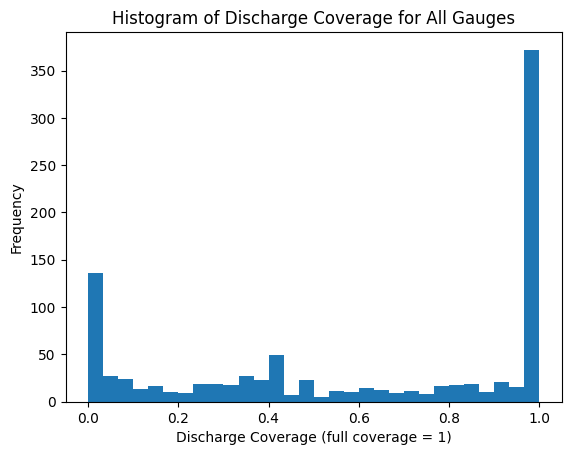

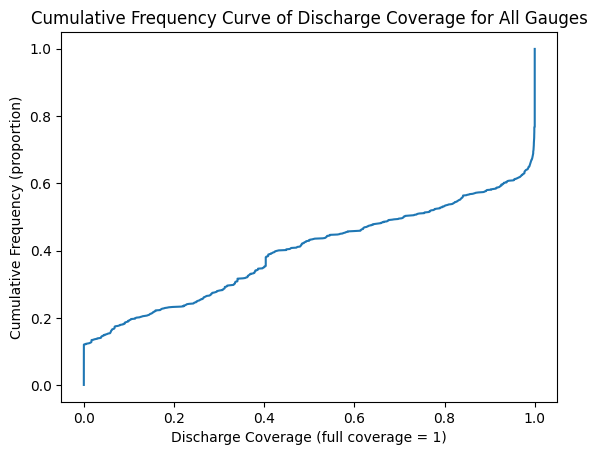

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the metadata CSV file
meta_df = pd.read_csv("meta_data.csv")

# Display summary statistics for the 'coverage' column
print(meta_df["coverage"].describe())

# Plot the histogram of discharge coverage
plt.hist(meta_df["coverage"], bins=30)
plt.xlabel('Discharge Coverage (full coverage = 1)')
plt.ylabel('Frequency')
plt.title('Histogram of Discharge Coverage for All Gauges')
plt.show()

# Sort the coverage values in ascending order
sorted_coverage = meta_df["coverage"].sort_values()

# Calculate the cumulative frequency
cumulative_frequency = sorted_coverage.rank(method='first') / len(sorted_coverage)

# Plot the cumulative frequency curve
plt.plot(sorted_coverage, cumulative_frequency)
plt.xlabel('Discharge Coverage (full coverage = 1)')
plt.ylabel('Cumulative Frequency (proportion)')
plt.title('Cumulative Frequency Curve of Discharge Coverage for All Gauges')
plt.show()


In [38]:
meta_df[meta_df["gauge_id"] == "04176605"]

,gauge_id,coverage,surface_ratio,num_rows,mean_discharge_train,mean_discharge,var_discharge_train,var_discharge
857,04176605,0.535748,NaN,8610,1.374975,1.391335,9.353698,9.509017


## Surface Area Ratio

In [5]:
meta_df.describe()

,coverage,surface_ratio,num_rows,mean_discharge_train,mean_discharge,var_discharge_train,var_discharge
count,975.000000,0.0,976.000000,834.000000,858.000000,834.000000,858.000000
mean,0.760999,NaN,12217.491803,13.810728,14.052451,629.364053,625.297928
std,0.356911,NaN,5746.317773,27.745137,28.872948,3451.389094,3487.422082
min,0.000000,NaN,0.000000,0.012622,0.008357,0.000000,0.000020
25%,0.532232,NaN,8492.750000,1.109410,1.056210,1.609960,1.383286
50%,1.000000,NaN,16071.000000,3.379257,3.338008,14.146105,14.050782
75%,1.000000,NaN,16071.000000,11.557962,11.739395,175.005934,162.728529
max,1.000000,NaN,16071.000000,222.108307,242.507848,69155.429690,71750.706280


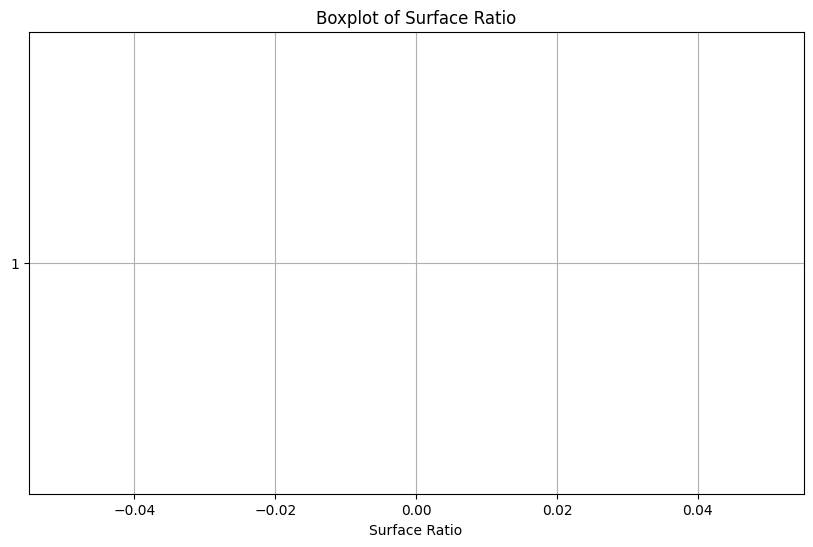

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the metadata CSV file
meta_df = pd.read_csv("meta_data.csv")

# Draw a boxplot of the "surface_ratio" column
plt.figure(figsize=(10, 6))
plt.boxplot(meta_df["surface_ratio"].dropna(), vert=False)
plt.xlabel('Surface Ratio')
plt.title('Boxplot of Surface Ratio')
plt.grid(True)
plt.show()

In [3]:
meta_df.columns

Index(['gauge_id', 'coverage', ' surface_ratio', 'num_rows',
       'mean_discharge_train', 'mean_discharge', 'var_discharge_train',
       'var_discharge'],
      dtype='object')

# Get the cumulative `mean` and `var` values

In [24]:
meta_df['mean_discharge'].mean()

14.052450715383355

In [73]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# Define the directory containing the CSV files
data_folder = 'csv_filtered'

# Initialize an empty list to store the data
data_list = []

# Iterate over all CSV files in the directory
for file_name in tqdm(os.listdir(data_folder)):
    if file_name.endswith('.csv'):
        file_path = os.path.join(data_folder, file_name)
        df = pd.read_csv(file_path, index_col='date')
        
        # Convert the index to datetime
        df.index = pd.to_datetime(df.index)
        
        # Filter the data to only include dates less than or equal to '31/12/2010'
        df = df[df.index <= '2010-12-31']
        
        # Add a very small value to "discharge", "prcp", and "swe" variables
        df['discharge'] += 1e-6
        df['prcp'] += 1e-6
        df['swe'] += 1e-6
        
        # Apply log transformation
        df['discharge'] = df['discharge'].apply(lambda x: np.log(x))
        df['prcp'] = df['prcp'].apply(lambda x: np.log(x))
        df['swe'] = df['swe'].apply(lambda x: np.log(x))
        
        data_list.append(df)

# Concatenate all data into a single DataFrame
combined_df = pd.concat(data_list)

# Collect mean and variance values for each variable
mean_variance_values = {}
variables = ['discharge', 'dayl', 'prcp', 'srad', 'swe', 'tmax', 'tmin', 'vp']

for variable in variables:
    mean_variance_values[variable] = {
        'mean': combined_df[variable].mean(),
        'variance': combined_df[variable].var()
    }

# Export the mean and variance values to a text file
with open('mean_variance_values.txt', 'w') as file:
    for variable, values in mean_variance_values.items():
        file.write(f"{variable}:\n")
        file.write(f"  mean: {values['mean']}\n")
        file.write(f"  variance: {values['variance']}\n")

100%|██████████| 976/976 [00:35<00:00, 27.78it/s]
C:\Users\ybrot\AppData\Local\Temp\ipykernel_238260\1934480157.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(data_list)


# Normalize the data

In [4]:
# z-score standardization

import os
import pandas as pd
import numpy as np
from tqdm import tqdm


# Define the directories
data_folder = 'csv_files'
output_folder = 'z-standardized_csv_files'

# Ensure the output directory exists
os.makedirs(output_folder, exist_ok=True)

# Read the mean and variance values from the text file
mean_variance_values = {}
with open('mean_variance_values.txt', 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 3):
        variable = lines[i].strip().replace(':', '')
        mean_value = float(lines[i+1].split(': ')[1])
        variance_value = float(lines[i+2].split(': ')[1])
        mean_variance_values[variable] = {'mean': mean_value, 'variance': variance_value}

# Iterate over all CSV files in the directory
for file_name in tqdm(os.listdir(data_folder)):
    if file_name.endswith('.csv'):
        file_path = os.path.join(data_folder, file_name)
        df = pd.read_csv(file_path, index_col='date')
        
        # Add a very small value to "discharge", "prcp", and "swe" variables
        df['discharge'] += 1e-6
        df['prcp'] += 1e-6
        df['swe'] += 1e-6
        
        # Apply log transformation
        df['discharge'] = df['discharge'].apply(lambda x: np.log(x))
        df['prcp'] = df['prcp'].apply(lambda x: np.log(x))
        df['swe'] = df['swe'].apply(lambda x: np.log(x))
        
        # Apply z-score standardization
        for variable in df.columns:
            mean_value = mean_variance_values[variable]['mean']
            variance_value = mean_variance_values[variable]['variance']
            df[variable] = (df[variable] - mean_value) / np.sqrt(variance_value)
        
        # Save the processed file to the output folder
        output_file_path = os.path.join(output_folder, file_name)
        df.to_csv(output_file_path)

100%|██████████| 976/976 [02:05<00:00,  7.77it/s]


In [4]:
from tqdm import tqdm
import pandas as pd
import os
import xarray as xr

def DataFrame_to_CDF(data: pd.DataFrame, 
                     output_dir: str,
                     output_name: str):
    """
    This function converts a pandas DataFrame to a NetCDF file, allowing missing values (NaN).
    
    Parameters
    ----------
    data : pd.DataFrame
        The DataFrame to be converted to NetCDF.
    output_dir : str
        The directory where the NetCDF file will be saved.
    output_name : str
        The name of the NetCDF file.
    ----------
    
    Data Requirements
    ----------
    - The DataFrame index must be named 'date'.
    - The DataFrame index must contain valid dates in the format '2000-01-01'.
    - Missing values (NaN) are allowed and will be retained in the NetCDF file.
    ----------
    """
    # Check if the index is named 'date'
    if data.index.name != 'date':
        raise ValueError("Index must be named 'date'")
    
    # Check if the index values are valid dates
    if not pd.to_datetime(data.index, errors='coerce').notna().all():
        raise ValueError("Index must contain valid dates in the format '2000-01-01'")
    
    # Ensure the directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Convert DataFrame to xarray Dataset and preserve NaN values
    ds = xr.Dataset.from_dataframe(data)
    ds = ds.fillna(float('nan'))  # Ensuring NaNs are explicitly preserved
    
    # Save to NetCDF
    ds.to_netcdf(f"{output_dir}/{output_name}.nc")

def convert_csv_to_cdf(input_folder: str, output_folder: str):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all CSV files in the input folder
    csv_files = [f for f in os.listdir(input_folder) if f.endswith('.csv')]
    
    for csv_file in tqdm(csv_files):
        # Construct the file path for the CSV file
        csv_file_path = os.path.join(input_folder, csv_file)
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(csv_file_path, index_col='date')
        df.index = pd.to_datetime(df.index)
        
        # Convert the DataFrame to a CDF file
        basin_id = os.path.splitext(csv_file)[0]
        DataFrame_to_CDF(df, output_folder, basin_id)

In [5]:
input_folder = 'csv_filtered_lagged'
output_folder = r'C:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\data\time_series'
convert_csv_to_cdf(input_folder, output_folder)

100%|██████████| 976/976 [00:36<00:00, 26.43it/s]


100%|██████████| 976/976 [00:15<00:00, 64.42it/s]


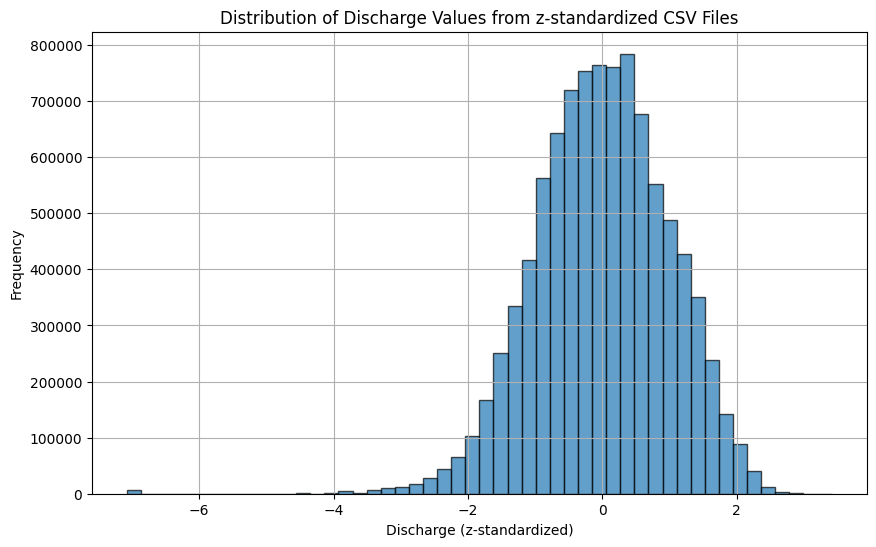

count    9.477673e+06
mean    -6.436944e-03
std      9.947950e-01
min     -7.073542e+00
25%     -6.655055e-01
50%      1.192988e-02
75%      6.800326e-01
max      3.416912e+00
dtype: float64


In [77]:
import os
import pandas as pd

import matplotlib.pyplot as plt

# Define the folder containing the z-standardized CSV files
folder = input_folder  # Already defined as 'z-standardized_csv_files'

# Collect all non-null discharge values from every CSV file
discharge_values = []
for file in tqdm(os.listdir(folder)):
    if file.endswith('.csv'):
        file_path = os.path.join(folder, file)
        df_csv = pd.read_csv(file_path, index_col='date')
        if 'discharge' in df_csv.columns:
            discharge_values.extend(df_csv['discharge'].dropna().tolist())
            
# Convert the list into a pandas Series for analysis
discharge_series = pd.Series(discharge_values)

# Plot the distribution of discharge values
plt.figure(figsize=(10, 6))
plt.hist(discharge_series, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Discharge (z-standardized)')
plt.ylabel('Frequency')
plt.title('Distribution of Discharge Values from z-standardized CSV Files')
plt.grid(True)
plt.show()

# Display summary statistics
print(discharge_series.describe())

In [67]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Define the training period
train_start = pd.to_datetime("1980-01-01")
train_end = pd.to_datetime("2010-12-31")

# Folder with CSV files
csv_folder = "z-standardized_csv_files"

# Initialize a list to collect discharge values
all_values = []

# Iterate over all CSV files in the folder
for file in tqdm(os.listdir(csv_folder)):
    if not file.endswith(".csv"):
        continue
    file_path = os.path.join(csv_folder, file)
    try:
        # Read CSV; assume 'date' column exists and parse dates
        df_temp = pd.read_csv(file_path, parse_dates=["date"])
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        continue
    
    # Check that 'discharge' exists
    if "discharge" not in df_temp.columns:
        continue
    
    # Filter rows within the training period and drop NaN discharge values
    df_train = df_temp[(df_temp["date"] >= train_start) & (df_temp["date"] <= train_end)]
    discharge_vals = df_train["discharge"].dropna().values
    if discharge_vals.size > 0:
        all_values.append(discharge_vals)

# Concatenate all discharge values
if all_values:
    all_discharge = np.concatenate(all_values)
    cum_mean = np.mean(all_discharge)
    cum_var = np.var(all_discharge, ddof=0)  # population variance
    print("Cumulative Mean (1980-01-01 to 2010-12-31):", cum_mean)
    print("Cumulative Variance (1980-01-01 to 2010-12-31):", cum_var)
else:
    print("No discharge data found in the specified training period.")

100%|██████████| 976/976 [00:23<00:00, 41.94it/s]

Cumulative Mean (1980-01-01 to 2010-12-31): -0.3526858412780893
Cumulative Variance (1980-01-01 to 2010-12-31): 0.002888537909793622


In [69]:
discharge_df = pd.DataFrame(
    {
        "dischage": all_discharge
    }
)

In [70]:
discharge_df.describe()

,dischage
count,6.629601e+06
mean,-3.526858e-01
std,5.374512e-02
min,-7.328542e-01
25%,-3.879095e-01
50%,-3.515595e-01
75%,-3.157738e-01
max,-1.690435e-01


In [2]:
import os
import pandas as pd
from tqdm import tqdm

# Define the input and output directories
input_dir = "csv_filtered"
output_dir = "csv_filtered_lagged"

# Create the output directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Loop over each CSV file in the input directory
for filename in tqdm(os.listdir(input_dir)):
    if filename.endswith(".csv"):
        file_path = os.path.join(input_dir, filename)
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        
        # Create the lagged discharge columns
        df["discharge_lag1"] = df["discharge"].shift(1)
        df["discharge_lag3"] = df["discharge"].shift(3)
        
        # Save the updated DataFrame to the output directory
        output_path = os.path.join(output_dir, filename)
        df.to_csv(output_path, index=False)


100%|██████████| 976/976 [01:23<00:00, 11.71it/s]


In [6]:
# Read the NetCDF file into an xarray Dataset
data_dir =  r'C:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\data\time_series\04159500.nc'
ds = xr.open_dataset(data_dir)

# Convert the Dataset to a pandas DataFrame
df_netcdf = ds.to_dataframe().reset_index()

# Display the first few rows
print(df_netcdf.head())

        date  discharge       dayl      prcp       srad        swe      tmax  \
0 1980-01-01   7.079145  31867.924  0.000000  108.02845  14.212575 -0.804336   
1 1980-01-02   5.833215  31915.162  0.259744  121.33306  13.518655  0.156368   
2 1980-01-03   4.870452  31966.256  0.987048  122.89435  14.505784 -2.247944   
3 1980-01-04   3.822738  32021.154  0.000000  161.67192  14.505784 -3.840720   
4 1980-01-05   3.256407  32079.834  0.000000  179.71663  14.505784 -1.185760   

       tmin         vp  discharge_lag1  discharge_lag3  
0 -4.773848  428.57584             NaN             NaN  
1 -4.348056  442.59060        7.079145             NaN  
2 -6.754416  368.41174        5.833215             NaN  
3 -9.979407  286.47990        4.870452        7.079145  
4 -8.248320  328.16922        3.822738        5.833215  


## Classify Basin Category

This notebook contains a code that classifies the basin in the following categories [1]:

- Agricultural Basin (AG): A basin must have more than 50% agricultural land and 5% or less urban land.

- Urban Basin (UR): A basin must have more than 25% urban land and 25% or less agricultural land.

- Undeveloped Basin (UD): A basin must have 5% or less urban land and 25% or less agricultural land.

- Mixed Basin (MX): If a basin doesn't meet any of the above conditions, it is classified as Mixed.

Each category is inferred from the static attributes crp_pc_sse (percentage of crop/agricultural land) and urb_pc_sse (percentage of urban land) [2].

The meaning of the static attributes can also be found in the study [2].

[1] Xia, X., Liu, X., Liu, J., Fang, K., Lu, L., Oymak, S., Currie, W. S., & Liu, T. (2025). Identifying trustworthiness challenges in deep learning models for continental-scale water quality prediction. arXiv. https://arxiv.org/abs/2503.09947

[2] Kratzert, F., Nearing, G., Addor, N., Erickson, T., Gauch, M., Gilon, O., Gudmundsson, L., Hassidim, A., Klotz, D., Nevo, S., Shalev, G., & Matias, Y. (n.d.). Caravan – A global community dataset for large‐sample hydrology. Retrieved from https://doi.org/10.5281/zenodo.7387919

In [2]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('attributes.csv')

# Function to classify each basin
def classify_basin(row):
    crop = row.get("crp_pc_sse", None)
    urban = row.get("urb_pc_sse", None)
    
    # Check if the necessary values are available
    if crop is None or urban is None:
        return "Unknown"
    
    if crop > 50 and urban <= 5:
        return "AG"  # Agricultural Basin
    elif urban > 25 and crop <= 25:
        return "UR"  # Urban Basin
    elif urban <= 5 and crop <= 25:
        return "UD"  # Undeveloped Basin
    else:
        return "MX"  # Mixed Basin

# Apply the classification function to each row and create a new column
df["basin_category"] = df.apply(classify_basin, axis=1)

# Overwrite the original CSV file with the updated DataFrame
df.to_csv('attributes.csv', index=False)

print("Basin category has been added and the CSV file has been overwritten.")


Basin category has been added and the CSV file has been overwritten.


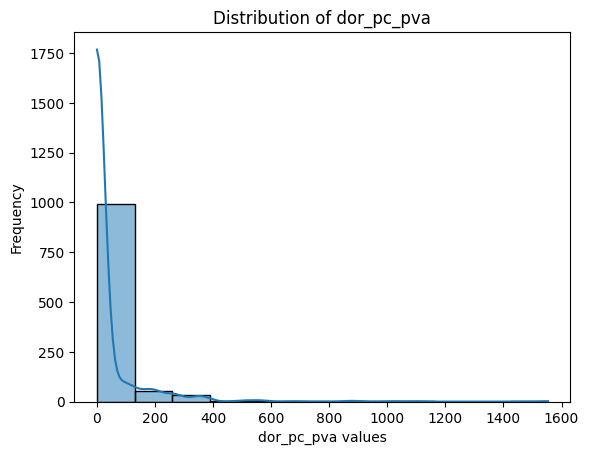

In [3]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plot the distribution of 'dor_pc_pva'
sns.histplot(df['dor_pc_pva'], kde=True)
plt.title('Distribution of dor_pc_pva')
plt.xlabel('dor_pc_pva values')
plt.ylabel('Frequency')
plt.show()

In [5]:
df['dor_pc_pva'].describe()

count    1088.000000
mean       32.642463
std       108.956250
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1553.000000
Name: dor_pc_pva, dtype: float64